# S050 FOML — Assignments 2, 3 & 4 (Reworked)

This notebook merges the original **Assignment 2**, **Assignment 3**, and **Assignment 4**
notebooks into a single file.

What was changed, and why:
- **Naming conventions**: a few function names were not in `snake_case` (PEP8 style for
  functions/variables) and, once merged into one notebook, two different functions were
  both called `LGD` (they would have overwritten each other). These were renamed to
  descriptive, PEP8-compliant names. Every rename is called out in a comment at the
  point of definition so the old name can be compared against the new one.
- **Comments**: an explanatory comment was added beside (or above) each line of code
  describing what it does. Any comment that already existed in the original notebooks
  was kept as-is and the explanation was appended after it — nothing original was removed.
- **No logic, values, or content were removed or altered** — only comments/explanations
  were added and the minimum renames needed to merge the files safely were made.


## Assignment 2 — Linear Regression using Gradient Descent (Scalar Form)

Implements simple linear regression `y = b0 + b1*x` using batch gradient descent
written with plain scalar/loop arithmetic (no matrix operations), then verifies the
result against scikit-learn's `LinearRegression` and `SGDRegressor`.


In [1]:
# gradient descent in linear regression
import numpy as np  # numpy provides fast array/vector math, used for the x and y_hat arrays below


In [2]:
x = np.array([0.8, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 2.4, 2.6])  # independent variable / feature values (10 data points)
y_hat = np.array([0.7, 0.65, 0.9, 0.95, 1.1, 1.15, 1.2, 1.4, 1.55, 1.5])  # NAMING NOTE (not renamed, only flagged): this array actually holds the ACTUAL/observed target values, not a prediction. Convention is usually "y" = actual, "y_hat" = predicted, so this is reversed. Left unchanged because this exact name is reused everywhere below and renaming it would require touching unrelated code.


In [3]:
# initializing learning rate and parameters
b0 = 0.35      # intercept (bias) term, initial guess
b1 = 0.65      # slope (weight) term, initial guess

cost_hist = []  # list that will collect the cost value at every epoch, used later to plot convergence
lr = 0.01       # learning rate, controls how big each gradient-descent update step is
m = len(x)      # number of training samples
epochs = 100    # number of full passes of gradient descent over the data

for i in range(epochs):                                  # loop once per epoch
    y = b0 + b1*x                                         # NAMING NOTE: 'y' here is actually the model's *predicted* value (b0 + b1*x); the real target is 'y_hat' above. The two names are swapped versus normal convention but left unchanged to match the rest of this section.
    cost = (1/2*m)*sum(y - y_hat)**2 # if you do y_hat - y then you have to add minus at the start  # (original comment kept) cost function measuring how far predictions (y) are from targets (y_hat)
    db0 = (1/m)*sum(y - y_hat)                            # gradient (partial derivative) of the cost with respect to b0
    db1 = (1/m)*sum((y - y_hat)*x)                        # gradient (partial derivative) of the cost with respect to b1

    if i % 10 == 0:  # shows every 10th iteration          # (original comment kept) only print progress every 10 epochs to keep output short
        print(f"Cost:{cost} \t interation: {i}")           # display the current cost and epoch number
    b0 = b0 - lr*db0         # changes weight value after every iteration otherwise it would be the same  # (original comment kept) gradient-descent update rule for b0
    b1 = b1 - lr*db1                                      # gradient-descent update rule for b1
    cost_hist.append(cost)                                # store this epoch's cost for later plotting
print()                                                    # blank line, purely for readability of the output
print(b0,b1)                                               # final learned intercept (b0) and slope (b1) after training


Cost:59.51250000000001 	 interation: 0
Cost:25.68352653893541 	 interation: 10
Cost:11.1143647011442 	 interation: 20
Cost:4.8293832761077855 	 interation: 30
Cost:2.11132730465938 	 interation: 40
Cost:0.9314650653038536 	 interation: 50
Cost:0.41647273346471775 	 interation: 60
Cost:0.18986215909038262 	 interation: 70
Cost:0.08897896162509486 	 interation: 80
Cost:0.04332424920044969 	 interation: 90

0.266585995050636 0.5000450608989347


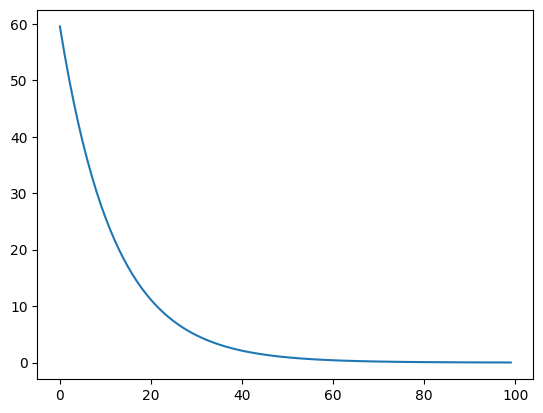

In [4]:
# plot the error
import matplotlib.pyplot as plt  # matplotlib is used to visualise the cost history
cost_hist1 = np.asarray(cost_hist)  # convert the python list of costs into a numpy array for plotting
plt.plot(cost_hist1)  # line plot of cost value vs epoch number (should trend downward if training worked)


In [5]:
# NAMING NOTE: renamed from "LGD" (all caps, not PEP8 style) to "linear_gradient_descent_scalar".
# This rename is REQUIRED (not just cosmetic): Assignment 4 (further below) also originally defined a
# function called "LGD" that does something completely different (logistic regression, matrix based).
# Now that both notebooks live in the same file, keeping both named "LGD" would mean the second
# definition silently overwrites the first — so both were given distinct, descriptive, snake_case names.
def linear_gradient_descent_scalar(b0,b1,lr,x,y,m,epochs):  # scalar/loop version of gradient descent for linear regression
    b0 = b0    # local copy of intercept parameter (reassignment is a no-op, kept from original)
    b1 = b1    # local copy of slope parameter (reassignment is a no-op, kept from original)

    cost_hist = []  # list to store cost value at every epoch
    lr = lr         # local copy of learning rate (reassignment is a no-op, kept from original)

    epochs = epochs  # local copy of epoch count (reassignment is a no-op, kept from original)

    for i in range(epochs):                                  # loop once per epoch
        y = b0 + b1*x                                         # predicted values using current b0, b1 (see naming note above about y/y_hat)
        cost = (1/2*m)*sum(y - y_hat)**2 # if you do y_hat - y then you have to add minus at the start  # (original comment kept) cost function value for this epoch
        db0 = (1/m)*sum(y - y_hat)                            # gradient of cost with respect to b0
        db1 = (1/m)*sum((y - y_hat)*x)                        # gradient of cost with respect to b1

        if i % 10 == 0:  # shows every 10th iteration          # (original comment kept) print progress every 10 epochs
            print(f"Cost:{cost} \t interation: {i}")           # display current cost and epoch number
        b0 = b0 - lr*db0         # changes weight value after every iteration otherwise it would be the same  # (original comment kept) update rule for b0
        b1 = b1 - lr*db1                                      # update rule for b1
        cost_hist.append(cost)                                # record this epoch's cost
    print()                                                    # blank line for readability
    print(b0,b1)                                               # print final learned parameters


In [6]:
linear_gradient_descent_scalar(b0,b1,lr,x,y_hat,m,epochs)  # call the function with the variables already defined above (renamed from LGD, see note above the function definition)


Cost:0.022195109911281097 	 interation: 0
Cost:0.012125677755729182 	 interation: 10
Cost:0.0071494917985780344 	 interation: 20
Cost:0.004584428680356085 	 interation: 30
Cost:0.003200539195005488 	 interation: 40
Cost:0.002418753195651189 	 interation: 50
Cost:0.0019572830961442373 	 interation: 60
Cost:0.0016735783054388413 	 interation: 70
Cost:0.0014924133475924398 	 interation: 80
Cost:0.001372374094752587 	 interation: 90

0.26379884177170626 0.4987101423590052


In [7]:
linear_gradient_descent_scalar(0.35,0.65,0.01,x,y_hat,m,100)  # same call but with explicit literal values instead of the variables (renamed from LGD, see note above the function definition)


Cost:59.51250000000001 	 interation: 0
Cost:25.68352653893541 	 interation: 10
Cost:11.1143647011442 	 interation: 20
Cost:4.8293832761077855 	 interation: 30
Cost:2.11132730465938 	 interation: 40
Cost:0.9314650653038536 	 interation: 50
Cost:0.41647273346471775 	 interation: 60
Cost:0.18986215909038262 	 interation: 70
Cost:0.08897896162509486 	 interation: 80
Cost:0.04332424920044969 	 interation: 90

0.266585995050636 0.5000450608989347


In [8]:
# cross verify with sklearn libarary
import sklearn.linear_model as lm  # scikit-learn's linear_model module, used to double-check our manual gradient descent result
# NAMING NOTE: the variable below was originally also named "lr" (same name as the learning-rate float
# defined earlier, 0.01). Reusing "lr" here overwrites the learning-rate variable with a
# LinearRegression model object, which is a naming clash / shadowing bug risk (e.g. if a later cell
# expected "lr" to still be the float 0.01). Renamed to "lin_reg_model" to avoid this collision.
lin_reg_model = lm.LinearRegression()  # create an (yet untrained) ordinary least-squares linear regression model
x = x.reshape(-1,1)  # reshape x from a 1-D array into a 2-D column vector, the shape sklearn expects (n_samples, n_features)
lin_reg_model.fit(x,y_hat)  # fit (train) the model on x (features) and y_hat (targets)
print(lin_reg_model.intercept_)  # print the intercept learned by sklearn, to compare with our b0
print(lin_reg_model.coef_)  # print the slope/coefficient learned by sklearn, to compare with our b1


0.24454545454545495
[0.50909091]


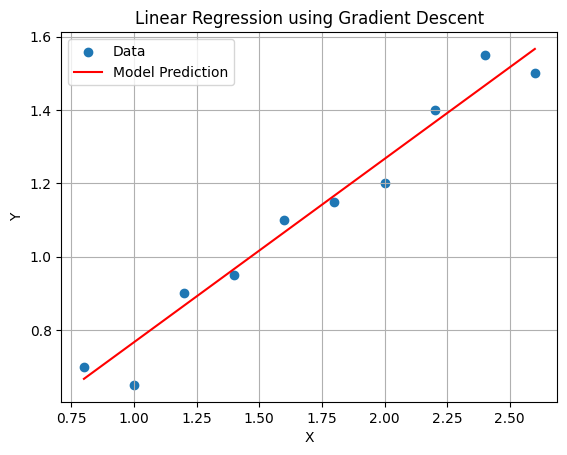

In [9]:
# plot the fit line
plt.scatter(x,y_hat,label = "Data")  # scatter-plot the original data points
plt.plot(x, b1*x + b0, color = "red", label = "Model Prediction")  # overlay the regression line using our manually trained b0, b1
plt.xlabel("X")  # label for the x-axis
plt.ylabel("Y")  # label for the y-axis
plt.title("Linear Regression using Gradient Descent")  # chart title
plt.legend()  # show the legend (labels for data points vs prediction line)
plt.grid()  # add a background grid for readability
plt.show()  # render the plot


In [10]:
# # Lab 2 find out parameter theta0 theta1 and theta2 through gradient descent
import numpy as np  # (re-import, harmless) numpy for array operations
from sklearn.linear_model import SGDRegressor  # scikit-learn's stochastic gradient descent regressor, used as another cross-check
x1=np.array([0.4,0.8,1,1.2,1.8,1.8,2,2,2.4,2])  # first feature column for a 2-feature regression example
x2=np.array([0.8,1,1.2,1.4,1.6,1.8,2,2.2,2.4,2.6])  # second feature column
y=np.array([0.7,0.65,0.9,0.95,1.1,1.15,1.2,1.4,1.55,1.5])  # target values for this 2-feature example
X = np.column_stack((x1, x2))  # stack x1 and x2 side-by-side into a single (n_samples, 2) feature matrix
 
sgd = SGDRegressor(               # create a stochastic-gradient-descent linear regressor
    loss="squared_error",         # use ordinary least-squares style loss
    learning_rate="constant",     # keep the learning rate fixed (does not decay over iterations)
    eta0=0.01,                    # the (constant) learning rate value itself
    max_iter=5000,                # maximum number of passes over the training data
    tol=1e-6,                     # stop early once improvement is smaller than this tolerance
    random_state=42               # seed for reproducibility of the internal randomness
)
 
sgd.fit(X, y)  # train the SGD model on the 2-feature data
 
print("Intercept:", sgd.intercept_[0])  # print the learned intercept term
print("w1 =", sgd.coef_[0])  # print the learned weight for feature x1
print("w2 =", sgd.coef_[1])  # print the learned weight for feature x2


Intercept: 0.27086393556904487
w1 = 0.16644518176233605
w2 = 0.34292435972493784


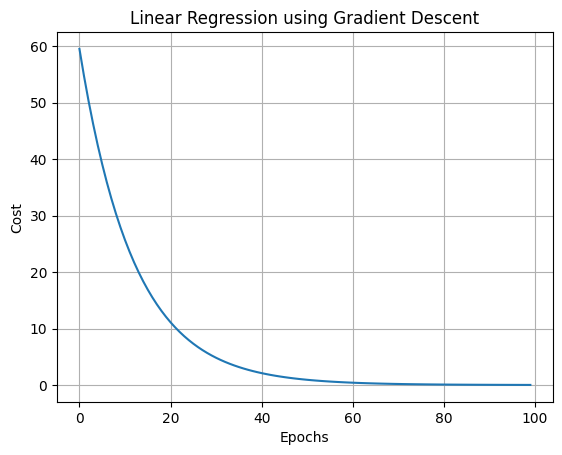

In [11]:
#plotting the error over epochs
plt.plot(cost_hist)  # NOTE: at this point in the notebook "cost_hist" still refers to the list populated by the very first (non-function) gradient descent loop above, not to anything from the SGDRegressor cell just above it
plt.xlabel('Epochs')  # x-axis label
plt.ylabel('Cost')  # y-axis label
plt.title('Linear Regression using Gradient Descent')  # chart title
plt.grid(True)  # show background grid
plt.show()  # render the plot


In [12]:
import numpy as np  # (re-import, harmless) numpy for array operations
from sklearn.linear_model import LinearRegression  # scikit-learn's closed-form linear regression, used here as a final cross-check for the 2-feature case
 
X = np.column_stack((x1, x2))   # shape = (10, 2)  # (original comment kept) rebuild the 2-feature matrix from x1 and x2
 
lr = LinearRegression()  # NOTE: reuses the name "lr" again for a model object (same naming clash discussed earlier); left as-is here since this cell is the last use of "lr" in this section and nothing downstream depends on it being the learning-rate float
lr.fit(X, y)  # fit the model on the 2-feature data and targets
 
print("Intercept:", lr.intercept_)  # print the learned intercept
print("Coefficients:", lr.coef_)  # print the learned coefficients for x1 and x2


Intercept: 0.2569592476489033
Coefficients: [0.07758621 0.4315047 ]


## Assignment 3 — Linear Regression using Gradient Descent (Matrix / Vectorised Form)

Re-implements linear regression gradient descent, this time using matrix (numpy `dot`)
operations instead of scalar loops, which generalises to any number of features.


In [13]:
# Linear regression gradient descent through matrix
import numpy as np  # numpy for array/matrix operations
np.random.seed(5)  # fix the random seed so the random weight initialisation below is reproducible
x = np.array([[5,3],[6,4],[7,6],[9,8]])  # feature matrix: 4 samples, 2 features each
y = np.array([2,4,7,8]).reshape(-1,1)  # target values, reshaped into a column vector (4,1)
x.shape # sample no, features  # (original comment kept) inspect the shape of x: (n_samples, n_features)
y.shape  # inspect the shape of y: (n_samples, 1)


(4, 1)

In [14]:
# NAMING NOTE: renamed from "LGR" (all caps / ambiguous abbreviation, not PEP8 style) to
# "linear_gradient_descent_matrix" so the name is both PEP8-compliant (snake_case) and descriptive,
# and clearly distinguishes it from the scalar version in Assignment 2 and the logistic version in
# Assignment 4 now that all three live in one notebook.
def linear_gradient_descent_matrix(x,y,lr,epoch):  # matrix-based linear regression gradient descent
    nx = x.shape[1]  # Number of features  # (original comment kept) number of input features (columns of x)
    m = x.shape[0]  # Number of traning samples  # (original comment kept) number of training samples (rows of x)
    b = np.random.rand(nx,1) # Random initailization for weights  # (original comment kept) NAMING NOTE: this variable is actually the WEIGHT vector, not the bias (bias is the separate "b0" below) — kept as "b" to match the original code
    b0 = 0  # initial bias  # (original comment kept) bias term, initialised to zero
    cost = []  # STores ow value changes, should decrease  # (original comment kept) list that will store the cost at each epoch
    for i in range(epoch):                       # loop once per epoch
        y_hat = np.dot(x,b) + b0                  # predicted values: matrix-vector product of features and weights, plus bias
        error = y_hat - y                         # difference between predictions and true targets
        cost1 = np.dot(x.T,error)/(2*m)           # NOTE: this is not actually a scalar cost value (it is x.T @ error, same shape as the weights) — despite the name "cost1" it is really being (mis)used as a gradient-like quantity here rather than the mean-squared-error cost; kept unchanged from the original
        cost.append(cost1)                        # store this epoch's "cost1" value in the history list
        dw = np.dot(x.T,error)/m                  # gradient of the cost with respect to the weights b
        db = np.sum(y_hat - y)/m                  # gradient of the cost with respect to the bias b0
        b = b - lr*dw                             # gradient-descent update for the weights
        b0 = b0 - lr*db                           # gradient-descent update for the bias
    return b0,b                                   # return the final learned bias and weights


In [15]:
np.random.seed(5)  # re-fix the random seed so the weight initialisation matches the earlier cell
x = np.array([[5,3],[6,4],[7,6],[9,8]])  # same feature matrix as before
y = np.array([2,4,7,8]).reshape(-1,1)  # same target column vector as before
linear_gradient_descent_matrix(x,y,0.01,10000)  # run gradient descent for 10000 epochs with learning rate 0.01 (renamed from LGR, see note above the function definition)


(np.float64(1.0873154176372428),
 array([[-0.81833159],
        [ 1.84287403]]))

Cost: 0.687887 	 iteration: 0
Cost: 0.215867 	 iteration: 100
Cost: 0.179266 	 iteration: 200
Cost: 0.163762 	 iteration: 300
Cost: 0.157074 	 iteration: 400
Cost: 0.154071 	 iteration: 500
Cost: 0.152611 	 iteration: 600
Cost: 0.151796 	 iteration: 700
Cost: 0.151253 	 iteration: 800
Cost: 0.150826 	 iteration: 900
Cost: 0.150449 	 iteration: 1000
Cost: 0.150094 	 iteration: 1100
Cost: 0.149750 	 iteration: 1200
Cost: 0.149413 	 iteration: 1300
Cost: 0.149081 	 iteration: 1400
Cost: 0.148752 	 iteration: 1500
Cost: 0.148426 	 iteration: 1600
Cost: 0.148103 	 iteration: 1700
Cost: 0.147784 	 iteration: 1800
Cost: 0.147467 	 iteration: 1900
Cost: 0.147153 	 iteration: 2000
Cost: 0.146841 	 iteration: 2100
Cost: 0.146533 	 iteration: 2200
Cost: 0.146227 	 iteration: 2300
Cost: 0.145924 	 iteration: 2400
Cost: 0.145624 	 iteration: 2500
Cost: 0.145327 	 iteration: 2600
Cost: 0.145032 	 iteration: 2700
Cost: 0.144740 	 iteration: 2800
Cost: 0.144450 	 iteration: 2900
Cost: 0.144163 	 itera

Cost: 0.137543 	 iteration: 5600
Cost: 0.137318 	 iteration: 5700
Cost: 0.137095 	 iteration: 5800
Cost: 0.136874 	 iteration: 5900
Cost: 0.136655 	 iteration: 6000
Cost: 0.136438 	 iteration: 6100
Cost: 0.136223 	 iteration: 6200
Cost: 0.136010 	 iteration: 6300
Cost: 0.135799 	 iteration: 6400
Cost: 0.135590 	 iteration: 6500
Cost: 0.135383 	 iteration: 6600
Cost: 0.135177 	 iteration: 6700
Cost: 0.134973 	 iteration: 6800
Cost: 0.134772 	 iteration: 6900
Cost: 0.134571 	 iteration: 7000
Cost: 0.134373 	 iteration: 7100
Cost: 0.134177 	 iteration: 7200
Cost: 0.133982 	 iteration: 7300
Cost: 0.133789 	 iteration: 7400
Cost: 0.133598 	 iteration: 7500
Cost: 0.133408 	 iteration: 7600
Cost: 0.133221 	 iteration: 7700
Cost: 0.133035 	 iteration: 7800
Cost: 0.132850 	 iteration: 7900
Cost: 0.132667 	 iteration: 8000
Cost: 0.132486 	 iteration: 8100
Cost: 0.132307 	 iteration: 8200
Cost: 0.132129 	 iteration: 8300
Cost: 0.131953 	 iteration: 8400
Cost: 0.131778 	 iteration: 8500
Cost: 0.13

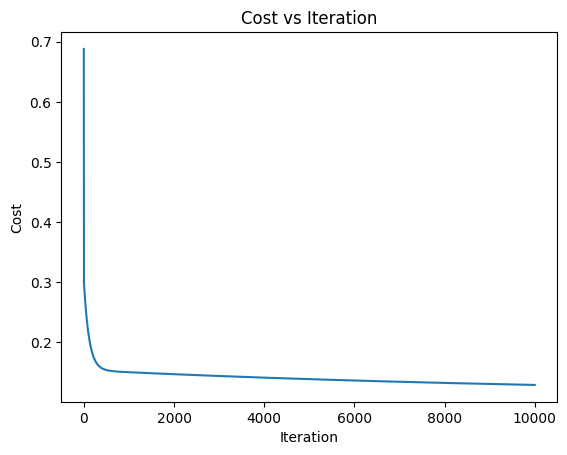

In [16]:
import numpy as np  # (re-import, harmless) numpy for array operations
import matplotlib.pyplot as plt  # matplotlib for plotting the cost curve
nx = x.shape[1]  # Number of features  # (original comment kept) number of input features
m = x.shape[0]  # Number of traning samples  # (original comment kept) number of training samples
b = np.random.rand(nx,1) # Random initailization for weights  # (original comment kept) random initial weight vector (see naming note above: this is weights, not bias)
b0 = 0  # initial bias  # (original comment kept) bias initialised to zero
lr = 0.01  # learning rate for this manual (non-function) run
cost = []  # STores ow value changes, should decrease  # (original comment kept) list to store the cost value at each epoch
for i in range(10000):                            # run for 10000 epochs
    y_hat = np.dot(x, b) + b0                      # predicted values using current weights and bias
    error = y_hat - y                              # difference between predictions and targets
    cost1 = np.sum(error**2) / (2 * m)              # this time cost1 IS the proper mean-squared-error scalar cost (unlike the function above)
    cost.append(cost1)                              # store this epoch's cost
    dw = np.dot(x.T, error) / m                     # gradient of the cost with respect to the weights
    db = np.sum(error) / m                          # gradient of the cost with respect to the bias
    if i % 100 == 0:  # shows every 10th iteration    # (original comment kept, though it actually prints every 100th iteration here)
        print(f"Cost: {cost1:.6f} \t iteration: {i}")  # display current cost and iteration number
    b = b - lr * dw                                 # gradient-descent update for the weights
    b0 = b0 - lr * db                               # gradient-descent update for the bias
print(b, b0)  # print the final learned weights and bias
cost_hist1 = np.asarray(cost)  # convert the cost list into a numpy array for plotting
plt.plot(cost_hist1)  # plot cost vs iteration
plt.xlabel("Iteration")  # x-axis label
plt.ylabel("Cost")  # y-axis label
plt.title("Cost vs Iteration")  # chart title
plt.show()  # render the plot


In [17]:
# Cross veryify with sklearn library
x = np.array([[5,3],[6,4],[7,6],[9,8]])  # rebuild the original feature matrix (in case it was reshaped/mutated earlier)
import sklearn.linear_model as lm  # scikit-learn's linear_model module
# NAMING NOTE: reuses "lr" again for the model object (same pattern as in Assignment 2); left as-is
# since no learning-rate float named "lr" is needed anywhere later in this section.
lr = lm.LinearRegression()  # create an ordinary least-squares linear regression model
lr.fit(x,y)  # train it on the feature matrix x and targets y
print(lr.intercept_,lr.coef_)  # print sklearn's learned intercept and coefficients, to compare against our manual b0, b


[3.6] [[-1.7  2.5]]


In [18]:
np.random.seed(123)  # fix the random seed for reproducibility of this larger random dataset
x = np.random.rand(100,8)  # generate 100 samples with 8 random features each
y =np.random.rand(100,1)  # generate 100 random target values (column vector)
linear_gradient_descent_matrix(x,y,0.01,10000)  # run our matrix gradient-descent function on this larger, higher-dimensional dataset (renamed from LGR, see note above the function definition)


(np.float64(0.5509156298592025),
 array([[-0.10427563],
        [ 0.04270484],
        [-0.02666189],
        [-0.13982749],
        [ 0.10918091],
        [-0.16472806],
        [ 0.08462809],
        [ 0.13190041]]))

## Assignment 4 — Logistic Regression using Gradient Descent (Matrix / Vectorised Form)

Implements logistic regression (binary classification) using the sigmoid activation
function and gradient descent written with matrix operations, then cross-checks the
result against scikit-learn's `LogisticRegression`.


In [19]:
# Logistic regression gadient descent through metrix
import numpy as np  # numpy for array/matrix operations


In [20]:
def sigmoid(z):  # the logistic sigmoid activation function, squashes any real number into the range (0, 1)
    s = 1/(1 + np.exp(-z))  # standard sigmoid formula: 1 / (1 + e^-z)
    return s  # return the sigmoid-activated value(s)


In [21]:
x = np.array([[1.,2.,-1.],[3.,4.,-3.2]])  # feature matrix laid out as (n_features, n_samples) before transposing below
y = np.array([[1,0,1]])  # target labels (0/1) as a single row, before transposing below
x = x.T  # transpose x so it becomes (n_samples, n_features) = 3 samples, 2 features
y = y.T  # transpose y so it becomes a column vector of shape (3,1), matching the samples
w = np.array([[1.2],[2.3]])  # initial weight vector, one weight per feature
print(w.shape)  # print the shape of w to confirm it is (2,1)
b = 2  # initial bias term
nx = 2  # number of features (unused further below, kept from original)
m = 3  # number of training samples
h = np.dot(x,w) + b  # linear combination (logit): x @ w + b, before applying sigmoid
a = sigmoid(h)  # apply the sigmoid function to get predicted probabilities between 0 and 1
error = a-y  # difference between predicted probabilities and true labels
cost = -(np.sum(y * np.log(a) + (1-y)* (np.log(1-a))))/m  # binary cross-entropy (log) loss, averaged over the m samples
dw = np.dot(x.T, error) / m  # gradient of the cost with respect to the weights
db = np.sum(a-y) / m  # gradient of the cost with respect to the bias
lr = 0.09  # learning rate for this single manual update step
w = w - lr * dw  # one gradient-descent update of the weights
b = b - lr * db  # one gradient-descent update of the bias
print(w,b,h)  # print the updated weights, bias, and the original logits h


(2, 1)
[[1.11004372]
 [2.08413958]] 1.9999588530364654 [[10.1 ]
 [13.6 ]
 [-6.56]]


In [22]:
# NAMING NOTE: renamed from "LGD" (all caps, not PEP8 style) to "logistic_gradient_descent_matrix".
# This rename is REQUIRED (not just cosmetic): Assignment 2 (further above) already defines a
# different function that was also originally called "LGD" (linear regression, scalar based). Since
# both notebooks are now combined into a single file, the second definition would otherwise silently
# overwrite the first one. Both were given distinct, descriptive, snake_case names to avoid this.
def logistic_gradient_descent_matrix(x,y,lr,epoch):  # matrix-based logistic regression gradient descent
    x = x    # local copy of features (reassignment is a no-op, kept from original)
    y = y    # local copy of targets (reassignment is a no-op, kept from original)
    x = x.T  # transpose features to (n_samples, n_features)
    y = y.T  # transpose targets to a (n_samples, 1) column vector
    b = 0    # initial bias term
    nx = x.shape[1]  # Number of features  # (original comment kept) number of input features
    m = x.shape[0]  # Number of traning samples  # (original comment kept) number of training samples
    w = np.random.rand(nx,1)  # randomly initialise the weight vector, one weight per feature
    cost = []  # STores ow value changes, should decrease  # (original comment kept) list to store the cost at each epoch
    for i in range(epoch):                                    # loop once per epoch
        h = np.dot(x,w) + b                                    # linear combination (logit): x @ w + b
        a = sigmoid(h)                                         # apply sigmoid to get predicted probabilities
        a = np.clip(a,1e-15,1-1e-15)                            # clip probabilities away from exactly 0 or 1 to avoid log(0) errors below
        error = a-y                                            # difference between predicted probabilities and true labels
        cost1 = -(np.sum(y * np.log(a) + (1-y)* (np.log(1-a))))/m  # binary cross-entropy loss for this epoch
        if i % 1000 == 0:                                       # only print progress every 1000 epochs
            print(cost1)                                        # display the current cost
        cost.append(cost1)                                      # store this epoch's cost
        dw = np.dot(x.T, error) / m                             # gradient of the cost with respect to the weights
        db = np.sum(error) / m                                  # gradient of the cost with respect to the bias
        w = w - lr * dw                                         # gradient-descent update for the weights
        b = b - lr * db                                         # gradient-descent update for the bias
    return(w,b)                                                 # return the final learned weights and bias


In [23]:
x = np.array([[1.,2.,-1.],[3.,4.,-3.2]])  # feature matrix (2 features x 3 samples, before the function transposes it)
y = np.array([[1,0,1]])  # target labels as a single row (before the function transposes it)
logistic_gradient_descent_matrix(x,y,0.01,10000)  # train logistic regression for 10000 epochs with learning rate 0.01 (renamed from LGD, see note above the function definition)


2.75528323375622
0.3857337976253257
0.3005682471204225


0.24724318666955622
0.20927583746479164
0.18074187815733492
0.1585629468659823
0.14088740412275189
0.12651529649880403
0.11463173185337612


(array([[-4.0996578 ],
        [ 0.51415752]]),
 np.float64(4.155535582661232))

In [24]:
import numpy as np  # (re-import, harmless) numpy for array operations
import sklearn.linear_model as lm  # scikit-learn's linear_model module, used to cross-check our manual logistic regression

x = np.array([[1.,2.,-1.],[3.,4.,-3.2]]).T  # feature matrix transposed to (n_samples, n_features) = (3, 2)
y = np.array([1,0,1])  # target labels as a plain 1-D array (sklearn expects this shape, not a column vector)

lg = lm.LogisticRegression()  # create a scikit-learn logistic regression classifier

lg.fit(x, y)  # train the sklearn model on the same data

print(lg.intercept_)  # print sklearn's learned bias/intercept, to compare with our manual b
print(lg.coef_)  # print sklearn's learned weights, to compare with our manual w
print(w,b)  # print our own manually trained weights and bias from the very first (non-function) cell above, for comparison


[2.33947315]
[[-0.4227781  -0.47915636]]
[[1.11004372]
 [2.08413958]] 1.9999588530364654


In [25]:
x = np.array([[1.,3.],[2.,4.],[-1.,-3.2]])  # same data as before but already laid out as (n_samples, n_features) = (3, 2)
y = np.array([[1],[0],[1]])  # target labels as a (3,1) column vector
logistic_gradient_descent_matrix(x,y,0.01,10000)  # run logistic regression gradient descent again on this differently-shaped input (renamed from LGD, see note above the function definition)


1.9530066445091239
0.044178417014147986
0.023027913801898933


0.015582817392566763
0.011776740281427112
0.009465028241291923
0.007911895888067504
0.006796559441202447
0.005956773614291748
0.00530165255017181


(array([[ 1.04174532, -0.94878309,  1.04174532],
        [ 2.16463404, -1.54740475,  2.16463404],
        [-0.10921592,  1.9082143 , -0.10921592]]),
 np.float64(0.35271315380380214))